# Parameterized Stabilizer Phase Profiles

This notebook compresses an existing single-plaquette stabilizer Rb phase profile into a low-dimensional ansatz, then reoptimizes the ansatz coefficients directly against the original GRAPE objective.

The full GRAPE profile is

$$
\phi_{\rm Rb}(t_k),\qquad k=0,\ldots,N-1.
$$

The parameterized optimizer replaces it by

$$
\alpha \mapsto \phi_{\rm Rb}(t_k;\alpha),
\qquad
\frac{\partial C}{\partial \alpha_j}
=\sum_k \frac{\partial C}{\partial \phi_k}
\frac{\partial \phi_k}{\partial \alpha_j}.
$$

Run `single_plaquet.ipynb` first if the saved profile JSON files are not present.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
if project_root.name == "stabilizer_readout":
    project_root = project_root.parent.parent
elif project_root.name == "examples":
    project_root = project_root.parent
example_directory = project_root / "examples" / "stabilizer_readout"
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(example_directory))

from single_plaquette_model import ReadoutParameters, make_blocks
from time_optimal_grape import (
    ControlLayout,
    GrapeOptimizer,
    GrapeProblem,
    OptimizerSettings,
    ParameterizedControlProjection,
    WeightedOverlapFidelity,
    assemble_parameters,
    constant_control_profile,
    evaluate_parameterized_controls,
    expand_parameterized_controls,
    fit_direct_fourier_phase,
    fit_integrated_detuning_phase,
    fit_single_harmonic_detuning_offset_phase,
    fit_spline_phase,
    fit_two_sine_phase,
    local_phase_parameter_indices,
    locked_parameter_indices,
    make_direct_fourier_parameterization,
    make_integrated_detuning_parameterization,
    make_single_harmonic_detuning_offset_parameterization,
    make_spline_parameterization,
    make_two_sine_phase_parameterization,
    optimize_parameterized_controls,
    parameterized_parameter_count,
    phase_profile_metrics,
    phase_sample_axis,
    unwrap_phase_profile,
)


## Load the Stabilizer Profile

Choose one of the saved profiles from `single_plaquet.ipynb`. The JSON file stores only the piecewise-constant Rb phase, so this notebook first reoptimizes the two scalar local phases while keeping all time controls fixed.

In [2]:
profile_filename = "rb_phase_profile_original.json"
profile_path = example_directory / profile_filename
if not profile_path.exists():
    raise FileNotFoundError(
        f"Missing saved profile {profile_path}. Run the save-profile block in single_plaquet.ipynb first."
    )

payload = json.loads(profile_path.read_text(encoding="utf-8"))
saved_phase = np.asarray(payload["phase_values"], dtype=np.float64)
samples = int(payload["samples"])
duration = float(payload["duration"])
omega0 = float(payload["omega0"])
reference_omega_rb = float(payload["reference_omega_rb"])

if saved_phase.shape != (samples,):
    raise ValueError(f"Saved profile shape {saved_phase.shape} does not match samples={samples}.")

parameters = ReadoutParameters(
    omega_rb=reference_omega_rb,
    b_rb_cs=10.0,
    b_edge=0.1,
    b_diag=0.0,
    rb_stark_shift=0.0,
    cs_stark_shift=0.0,
)
layout = ControlLayout(
    time_control_names=("phi_rb", "phi_cs", "ratio_cs"),
    local_phase_names=("theta_rb", "theta_cs"),
    samples=samples,
)
settings = OptimizerSettings(method="BFGS", max_iterations=800, gradient_tolerance=1e-6, display=False)
problem = GrapeProblem(
    blocks=make_blocks(parameters=parameters),
    control_layout=layout,
    duration=duration,
    objective=WeightedOverlapFidelity(normalizer=16.0**2),
    optimizer_settings=settings,
)
saved_parameters = assemble_parameters(
    layout=layout,
    time_controls={
        "phi_rb": saved_phase,
        "phi_cs": constant_control_profile(samples=samples, value=0.0),
        "ratio_cs": constant_control_profile(samples=samples, value=0.0),
    },
    local_phases={"theta_rb": np.pi, "theta_cs": 0.0},
)

time_locked_indices = locked_parameter_indices(
    layout=layout,
    time_control_names=("phi_rb", "phi_cs", "ratio_cs"),
    local_phase_names=(),
)
reference_result = GrapeOptimizer(problem).optimize_with_locked_parameters(
    initial_parameters=saved_parameters,
    locked_parameter_indices=time_locked_indices,
)
reference_controls = layout.unpack(reference_result.parameters)
reference_phase = reference_controls.time_controls["phi_rb"]
print(f"profile: {payload['profile_label']}")
print(f"reference fidelity after local-phase fit: {reference_result.fidelity:.12f}")
print(f"theta_rb={reference_controls.local_phases['theta_rb']:.8f}, theta_cs={reference_controls.local_phases['theta_cs']:.8f}")


profile: original
reference fidelity after local-phase fit: 0.987461213991
theta_rb=3.25239578, theta_cs=0.00000000


## Ansatz Definitions

The four trial families are:

Direct Fourier phase:

$$
\phi(t)=a_0+\sum_{n=1}^M a_n\sin(2\pi n t/T)+b_n\cos(2\pi n t/T).
$$

Integrated-detuning Fourier:

$$
\Delta(t)=\sum_{n=1}^M c_n\sin(n\pi t/T),\qquad
\phi(t)=\phi_0+\int_0^t\Delta(t')dt'.
$$

Two-sine direct phase:

$$
\phi(t)=\phi_0+a_1\sin(2\pi t/T)+b_1\cos(2\pi t/T)+a_2\sin(\omega t)+b_2\cos(\omega t).
$$

This is equivalent to a sum of two phase-shifted sine waves. The first has exactly one period over $T$; the second fits its angular frequency $\omega$.

Cubic spline phase:

$$
\phi(t)=\sum_j s_j B_j(t).
$$


In [3]:
@dataclass(frozen=True)
class AnsatzCase:
    key: str
    label: str
    color: str
    parameterization_name: str
    shape_parameter: int


two_sine_fixed_omega = 2.0 * np.pi / duration
two_sine_omega_min = 0.1 * two_sine_fixed_omega
two_sine_omega_max = 8.0 * two_sine_fixed_omega
two_sine_omega_grid_size = 200

ansatz_cases = (
    AnsatzCase(
        key="fourier_m4",
        label="direct Fourier M=4",
        color="tab:blue",
        parameterization_name="direct_fourier",
        shape_parameter=4,
    ),
    AnsatzCase(
        key="detuning_m4",
        label="integrated detuning M=4",
        color="tab:orange",
        parameterization_name="integrated_detuning",
        shape_parameter=4,
    ),
    AnsatzCase(
        key="two_sine",
        label="two-sine fitted omega",
        color="tab:red",
        parameterization_name="two_sine",
        shape_parameter=0,
    ),
    AnsatzCase(
        key="spline_k8",
        label="cubic spline K=8",
        color="tab:green",
        parameterization_name="spline",
        shape_parameter=8,
    ),
)


In [4]:
def make_parameterization_for_case(ansatz_case: AnsatzCase):
    if ansatz_case.parameterization_name == "direct_fourier":
        return make_direct_fourier_parameterization(
            time_control_name="phi_rb",
            duration=duration,
            samples=samples,
            order=ansatz_case.shape_parameter,
        )
    if ansatz_case.parameterization_name == "integrated_detuning":
        return make_integrated_detuning_parameterization(
            time_control_name="phi_rb",
            duration=duration,
            samples=samples,
            order=ansatz_case.shape_parameter,
        )
    if ansatz_case.parameterization_name == "two_sine":
        return make_two_sine_phase_parameterization(
            time_control_name="phi_rb",
            duration=duration,
            samples=samples,
        )
    if ansatz_case.parameterization_name == "spline":
        return make_spline_parameterization(
            time_control_name="phi_rb",
            duration=duration,
            samples=samples,
            knot_count=ansatz_case.shape_parameter,
        )
    raise ValueError(f"Unknown parameterization name {ansatz_case.parameterization_name!r}.")


def fit_coefficients_for_case(ansatz_case: AnsatzCase, phase_profile: np.ndarray) -> np.ndarray:
    if ansatz_case.parameterization_name == "direct_fourier":
        return fit_direct_fourier_phase(
            phase_profile=phase_profile,
            duration=duration,
            order=ansatz_case.shape_parameter,
        )
    if ansatz_case.parameterization_name == "integrated_detuning":
        return fit_integrated_detuning_phase(
            phase_profile=phase_profile,
            duration=duration,
            order=ansatz_case.shape_parameter,
        )
    if ansatz_case.parameterization_name == "two_sine":
        return fit_two_sine_phase(
            phase_profile=phase_profile,
            duration=duration,
            omega_min=two_sine_omega_min,
            omega_max=two_sine_omega_max,
            omega_grid_size=two_sine_omega_grid_size,
        )
    if ansatz_case.parameterization_name == "spline":
        return fit_spline_phase(
            phase_profile=phase_profile,
            duration=duration,
            knot_count=ansatz_case.shape_parameter,
        )
    raise ValueError(f"Unknown parameterization name {ansatz_case.parameterization_name!r}.")


local_phase_indices = local_phase_parameter_indices(
    layout=layout,
    local_phase_names=("theta_rb", "theta_cs"),
)

projections: dict[str, ParameterizedControlProjection] = {}
initial_ansatz_parameters: dict[str, np.ndarray] = {}
for ansatz_case in ansatz_cases:
    time_parameterization = make_parameterization_for_case(ansatz_case=ansatz_case)
    phase_coefficients = fit_coefficients_for_case(
        ansatz_case=ansatz_case,
        phase_profile=reference_phase,
    )
    projection = ParameterizedControlProjection(
        layout=layout,
        base_parameters=reference_result.parameters,
        time_control_parameterizations=(time_parameterization,),
        direct_parameter_indices=local_phase_indices,
    )
    direct_initial = reference_result.parameters[np.asarray(local_phase_indices, dtype=np.int64)]
    initial_ansatz = np.concatenate((phase_coefficients, direct_initial)).astype(np.float64)
    if initial_ansatz.shape != (parameterized_parameter_count(projection=projection),):
        raise ValueError(f"Invalid initial ansatz shape for {ansatz_case.key}: {initial_ansatz.shape}.")
    projections[ansatz_case.key] = projection
    initial_ansatz_parameters[ansatz_case.key] = initial_ansatz


## Fit Quality Before Reoptimization

This step checks the least-squares compression alone. The local phases are inherited from the fixed-profile reference.

In [5]:
fit_rows: list[tuple[str, int, float, float, float, float]] = []
fit_full_parameters: dict[str, np.ndarray] = {}
for ansatz_case in ansatz_cases:
    projection = projections[ansatz_case.key]
    ansatz = initial_ansatz_parameters[ansatz_case.key]
    full_parameters = expand_parameterized_controls(
        projection=projection,
        ansatz_parameters=ansatz,
    )
    fit_full_parameters[ansatz_case.key] = full_parameters
    fit_cost, _fit_gradient = evaluate_parameterized_controls(
        problem=problem,
        projection=projection,
        ansatz_parameters=ansatz,
    )
    fit_controls = layout.unpack(full_parameters)
    metrics = phase_profile_metrics(
        reference_profile=reference_phase,
        candidate_profile=fit_controls.time_controls["phi_rb"],
        duration=duration,
    )
    fit_rows.append(
        (
            ansatz_case.label,
            parameterized_parameter_count(projection=projection),
            1.0 - fit_cost,
            metrics.rms_fit_error,
            metrics.max_abs_detuning,
            metrics.max_abs_detuning_slope,
        )
    )

print("label | parameters | fit fidelity | rms phase error | max |dphi/dt| | max |d2phi/dt2|")
for row in fit_rows:
    print(f"{row[0]} | {row[1]} | {row[2]:.10f} | {row[3]:.3e} | {row[4]:.3e} | {row[5]:.3e}")


label | parameters | fit fidelity | rms phase error | max |dphi/dt| | max |d2phi/dt2|
direct Fourier M=4 | 11 | 0.9872205834 | 9.507e-03 | 1.940e-01 | 2.229e-01
integrated detuning M=4 | 7 | 0.9873438194 | 2.032e-02 | 2.155e-01 | 2.197e-01
two-sine fitted omega | 8 | 0.9872700995 | 9.126e-03 | 1.837e-01 | 1.777e-01
cubic spline K=8 | 10 | 0.9872715690 | 8.214e-03 | 1.650e-01 | 2.357e-01


## Low-Dimensional Reoptimization

Only the ansatz coefficients and the two local phases are optimized. `phi_cs` and `ratio_cs` remain fixed by the base vector, so this test isolates whether the Rb phase can be represented compactly.

In [6]:
parameterized_results = {}
for ansatz_case in ansatz_cases:
    result = optimize_parameterized_controls(
        problem=problem,
        projection=projections[ansatz_case.key],
        initial_ansatz_parameters=initial_ansatz_parameters[ansatz_case.key],
        locked_ansatz_parameter_indices=(),
    )
    parameterized_results[ansatz_case.key] = result
    print(
        f"{ansatz_case.label}: fidelity={result.fidelity:.12f}, "
        f"infidelity={result.infidelity:.3e}, iterations={result.iterations}, success={result.success}"
    )


direct Fourier M=4: fidelity=0.987225760168, infidelity=1.277e-02, iterations=24, success=True
integrated detuning M=4: fidelity=0.987413499990, infidelity=1.259e-02, iterations=9, success=True
two-sine fitted omega: fidelity=0.987388463576, infidelity=1.261e-02, iterations=424, success=True
cubic spline K=8: fidelity=0.987436444445, infidelity=1.256e-02, iterations=27, success=True


## Profile Comparison

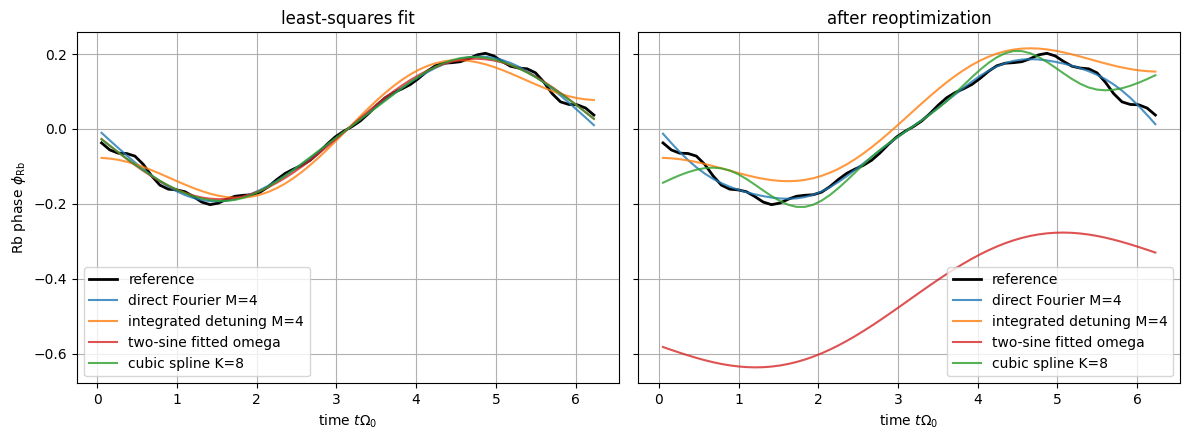

In [7]:
time_axis = phase_sample_axis(duration=duration, samples=samples) * omega0
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
axes[0].plot(time_axis, unwrap_phase_profile(reference_phase), color="black", linewidth=2.0, label="reference")
axes[1].plot(time_axis, unwrap_phase_profile(reference_phase), color="black", linewidth=2.0, label="reference")
for ansatz_case in ansatz_cases:
    fit_controls = layout.unpack(fit_full_parameters[ansatz_case.key])
    optimized_controls = layout.unpack(parameterized_results[ansatz_case.key].full_parameters)
    axes[0].plot(
        time_axis,
        unwrap_phase_profile(fit_controls.time_controls["phi_rb"]),
        color=ansatz_case.color,
        alpha=0.8,
        label=ansatz_case.label,
    )
    axes[1].plot(
        time_axis,
        unwrap_phase_profile(optimized_controls.time_controls["phi_rb"]),
        color=ansatz_case.color,
        alpha=0.8,
        label=ansatz_case.label,
    )
axes[0].set_title("least-squares fit")
axes[1].set_title("after reoptimization")
for axis in axes:
    axis.set_xlabel(r"time $t\Omega_0$")
    axis.grid(True)
    axis.legend()
axes[0].set_ylabel(r"Rb phase $\phi_{\rm Rb}$")
fig.tight_layout()
plt.show()


## Final Metrics

In [ ]:
print("label | parameters | optimized fidelity | rms phase change | max |dphi/dt| | max |d2phi/dt2|")
for ansatz_case in ansatz_cases:
    optimized_controls = layout.unpack(parameterized_results[ansatz_case.key].full_parameters)
    metrics = phase_profile_metrics(
        reference_profile=reference_phase,
        candidate_profile=optimized_controls.time_controls["phi_rb"],
        duration=duration,
    )
    print(
        f"{ansatz_case.label} | "
        f"{parameterized_parameter_count(projection=projections[ansatz_case.key])} | "
        f"{parameterized_results[ansatz_case.key].fidelity:.10f} | "
        f"{metrics.rms_fit_error:.3e} | "
        f"{metrics.max_abs_detuning:.3e} | "
        f"{metrics.max_abs_detuning_slope:.3e}"
    )


## Detuning-Offset Single-Harmonic Scan

For MC simulations with a static Rb detuning offset, use

$$
\Delta(t)=\delta+c_1\sin(\pi t/T),
$$

so that

$$
\phi(t)=\phi_0+\delta t+
rac{T c_1}{\pi}\left[1-\cos(\pi t/T)
ight].
$$

The scan below fixes each detuning offset `delta` and reoptimizes only `phi0`, `c1`, `theta_rb`, and `theta_cs`. The saved JSON contains both the analytic parameters and sampled phase values for direct MC use.

In [ ]:
@dataclass(frozen=True)
class DetuningScanPoint:
    detuning_offset: float
    fidelity: float
    infidelity: float
    phi0: float
    c1: float
    theta_rb: float
    theta_cs: float
    success: bool
    iterations: int
    phase_values: list[float]


def optimize_c1_profile_for_detuning(detuning_offset: float) -> DetuningScanPoint:
    parameterization = make_single_harmonic_detuning_offset_parameterization(
        time_control_name="phi_rb",
        duration=duration,
        samples=samples,
        detuning_offset=detuning_offset,
    )
    projection = ParameterizedControlProjection(
        layout=layout,
        base_parameters=reference_result.parameters,
        time_control_parameterizations=(parameterization,),
        direct_parameter_indices=local_phase_indices,
    )
    phase_coefficients = fit_single_harmonic_detuning_offset_phase(
        phase_profile=reference_phase,
        duration=duration,
        detuning_offset=detuning_offset,
    )
    direct_initial = reference_result.parameters[np.asarray(local_phase_indices, dtype=np.int64)]
    initial_ansatz = np.concatenate((phase_coefficients, direct_initial)).astype(np.float64)
    result = optimize_parameterized_controls(
        problem=problem,
        projection=projection,
        initial_ansatz_parameters=initial_ansatz,
        locked_ansatz_parameter_indices=(),
    )
    controls = layout.unpack(result.full_parameters)
    return DetuningScanPoint(
        detuning_offset=float(detuning_offset),
        fidelity=float(result.fidelity),
        infidelity=float(result.infidelity),
        phi0=float(result.ansatz_parameters[0]),
        c1=float(result.ansatz_parameters[1]),
        theta_rb=float(result.ansatz_parameters[2]),
        theta_cs=float(result.ansatz_parameters[3]),
        success=bool(result.success),
        iterations=int(result.iterations),
        phase_values=np.angle(np.exp(1j * controls.time_controls["phi_rb"])).astype(np.float64).tolist(),
    )


detuning_offsets = np.linspace(-0.20, 0.20, 41, dtype=np.float64)
detuning_scan_points = tuple(
    optimize_c1_profile_for_detuning(detuning_offset=float(detuning_offset))
    for detuning_offset in detuning_offsets
)

best_detuning_point = max(detuning_scan_points, key=lambda point: point.fidelity)
print(
    "best detuning point: "
    f"delta={best_detuning_point.detuning_offset:.6f}, "
    f"fidelity={best_detuning_point.fidelity:.12f}, "
    f"phi0={best_detuning_point.phi0:.12f}, "
    f"c1={best_detuning_point.c1:.12f}"
)
print("delta | fidelity | phi0 | c1 | theta_rb | success")
for point in detuning_scan_points:
    print(
        f"{point.detuning_offset:+.6f} | "
        f"{point.fidelity:.10f} | "
        f"{point.phi0:+.8f} | "
        f"{point.c1:+.8f} | "
        f"{point.theta_rb:+.8f} | "
        f"{point.success}"
    )


In [ ]:
detuning_scan_deltas = np.asarray(
    [point.detuning_offset for point in detuning_scan_points],
    dtype=np.float64,
)
detuning_scan_fidelities = np.asarray(
    [point.fidelity for point in detuning_scan_points],
    dtype=np.float64,
)

plt.figure(figsize=(7, 4.5))
plt.plot(detuning_scan_deltas / omega0, detuning_scan_fidelities, marker="o", linewidth=1.6)
plt.axvline(best_detuning_point.detuning_offset / omega0, color="black", linewidth=0.8, alpha=0.5)
plt.xlabel(r"detuning offset $\delta/\Omega_0$")
plt.ylabel(r"fidelity $F$")
plt.title(r"Best $\Delta(t)=\delta+c_1\sin(\pi t/T)$ profile for each detuning")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
detuning_scan_output_path = example_directory / "rb_phase_profile_c1_detuning_scan.json"
detuning_scan_payload: dict[str, object] = {
    "profile_label": "single_harmonic_detuning_offset_scan",
    "control_name": "phi_rb",
    "parameterization": "integrated_detuning_single_harmonic_with_offset",
    "detuning_definition": "Delta(t) = delta + c1 * sin(pi * t / duration)",
    "phase_definition": "phi(t) = phi0 + delta * t + duration * c1 / pi * (1 - cos(pi * t / duration))",
    "time_domain": "0 <= t <= duration",
    "omega0": float(omega0),
    "reference_omega_rb": float(reference_omega_rb),
    "duration": float(duration),
    "duration_omega0": float(duration * omega0),
    "samples": int(samples),
    "detuning_units": "angular frequency in the same units as omega0",
    "phase_units": "radians",
    "points": [point.__dict__ for point in detuning_scan_points],
    "best_point": best_detuning_point.__dict__,
}
detuning_scan_output_path.write_text(
    json.dumps(detuning_scan_payload, indent=2),
    encoding="utf-8",
)
print(f"saved detuning scan profiles: {detuning_scan_output_path}")
